# Parte 2 — Face Recognition con Contrastive Learning

Dataset: **LFW (Labeled Faces in the Wild)**. Pares etiquetados: misma persona (y=1) o distintas (y=0). Splits oficiales DevTrain (2200 pares) y DevTest (1000 pares).

## Actividad 5 — Preguntas teóricas


### a) ¿Por qué no se usa clasificación clásica con softmax en reconocimiento facial? ¿Qué problema surge con identidades nuevas?

El problema con softmax es que entrena al modelo para distinguir entre un conjunto fijo de personas conocidas. Si aparece alguien nuevo, el modelo no sabe qué hacer porque nunca lo vio durante el entrenamiento, y agregar una identidad nueva obligaría a reentrenar todo desde cero.
La solución es aprender un espacio de embeddings donde la distancia entre dos imágenes refleje qué tan parecidas son las personas, sin importar si esa persona fue vista durante el entrenamiento o no. Así, reconocer a alguien se reduce a comparar distancias en lugar de clasificar entre categorías fijas.


### b) Diferencia entre contrastive loss y triplet loss. ¿Cuándo conviene cada una?

Ambas funciones buscan lo mismo: que embeddings de la misma persona estén cerca y los de personas distintas estén lejos. La diferencia está en cómo lo hacen.
Contrastive loss trabaja con pares de imágenes y una etiqueta que indica si son la misma persona o no. Es más simple de implementar y funciona bien cuando los datos ya vienen organizados en pares.
Triplet loss trabaja con tríos: una imagen de referencia, una de la misma persona y una de alguien distinto. Esto le da al modelo más contexto relativo y genera gradientes más informativos, lo que lo hace más adecuado para escenarios con muchas identidades y pocos ejemplos por persona. La contra es que requiere más cuidado al armar los tríos para que el entrenamiento no colapse.


### c) ¿Qué significa geométricamente que dos embeddings estén "cerca"? ¿Cómo se relaciona con similitud entre rostros?

Cada imagen de rostro se transforma en un punto en un espacio de alta dimensión. Que dos embeddings estén "cerca" significa simplemente que la distancia entre esos dos puntos es pequeña, lo que el modelo interpreta como que pertenecen a la misma persona.
Durante el entrenamiento, el modelo aprende a agrupar los embeddings de la misma persona en regiones compactas del espacio, y a separar los de personas distintas. En la práctica, comparar dos rostros se reduce a calcular esa distancia y compararla con un umbral: si es menor, son la misma persona; si no, son distintas.

### Visualización de Pares

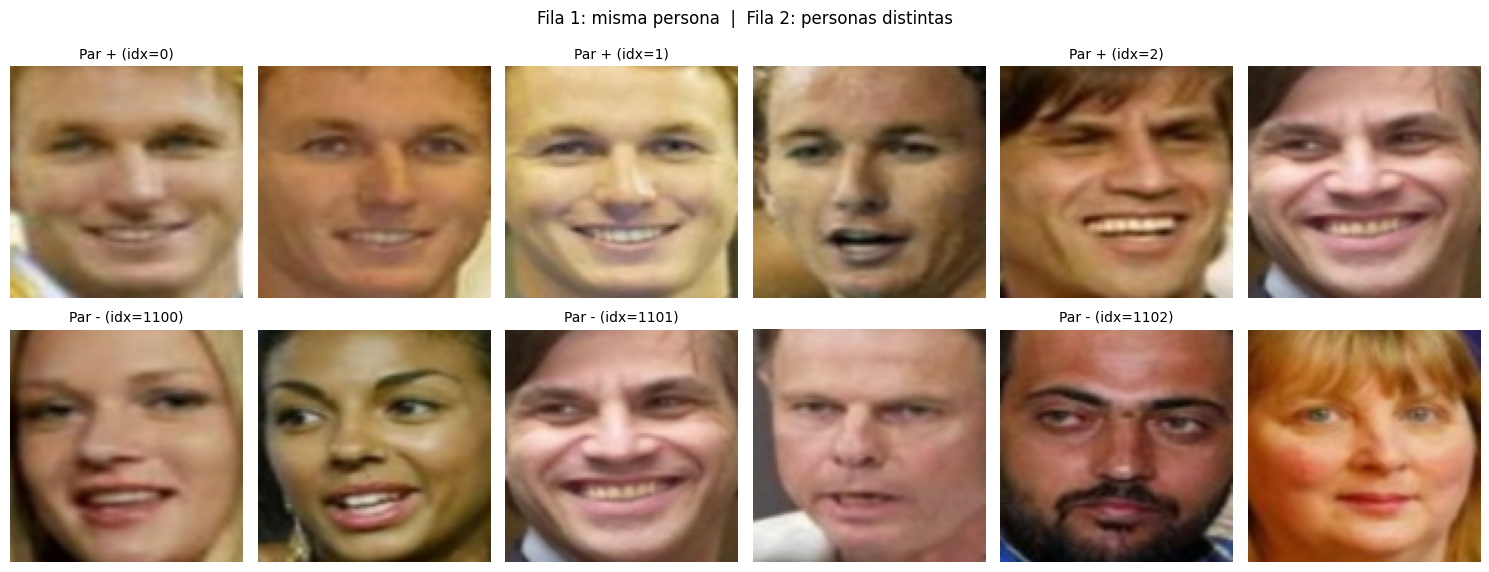

In [59]:
from PIL import Image

def desnormalizar(img_tensor):
    img = img_tensor.clone() * 0.5 + 0.5
    return img.permute(1, 2, 0).numpy().clip(0, 1)

labels_arr = train_dataset.labels
pos_idx    = np.where(labels_arr == 1)[0][:3]
neg_idx    = np.where(labels_arr == 0)[0][:3]

fig, axes = plt.subplots(2, 6, figsize=(15, 6))

for col, idx in enumerate(pos_idx):
    img1, img2, _ = train_dataset[int(idx)]
    axes[0, col*2].imshow(desnormalizar(img1));   axes[0, col*2].axis('off')
    axes[0, col*2+1].imshow(desnormalizar(img2)); axes[0, col*2+1].axis('off')
    axes[0, col*2].set_title(f'Par + (idx={idx})', fontsize=10)

for col, idx in enumerate(neg_idx):
    img1, img2, _ = train_dataset[int(idx)]
    axes[1, col*2].imshow(desnormalizar(img1));   axes[1, col*2].axis('off')
    axes[1, col*2+1].imshow(desnormalizar(img2)); axes[1, col*2+1].axis('off')
    axes[1, col*2].set_title(f'Par - (idx={idx})', fontsize=10)

plt.suptitle('Fila 1: misma persona  |  Fila 2: personas distintas', fontsize=12)
plt.tight_layout(); plt.show()


## Actividad 6 - Siamese Network 

In [60]:
from sklearn.datasets import fetch_lfw_pairs

lfw_train = fetch_lfw_pairs(subset='train', funneled=True, color=True, resize=1.0)
lfw_test  = fetch_lfw_pairs(subset='test',  funneled=True, color=True, resize=1.0)

print(f"Train: {len(lfw_train.target)} pares")
print(f"Test:  {len(lfw_test.target)} pares")
print(f"Shape de cada par: {lfw_train.pairs.shape[1:]}  (2 imágenes RGB)")
print(f"Etiquetas: {lfw_train.target_names}")

Train: 2200 pares
Test:  1000 pares
Shape de cada par: (2, 125, 94, 3)  (2 imágenes RGB)
Etiquetas: ['Different persons' 'Same person']


In [61]:
from torchvision import transforms
# --- Dataset wrapper ---
class LFWPairsDataset(Dataset):
    """Wrapper de los pares de sklearn como Dataset de PyTorch."""
    def __init__(self, lfw_obj, transform=None):
        self.pairs     = (lfw_obj.pairs * 255).astype(np.uint8)
        self.labels    = lfw_obj.target.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img1 = Image.fromarray(self.pairs[idx, 0])
        img2 = Image.fromarray(self.pairs[idx, 1])
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
        return img1, img2, self.labels[idx]

transform = transforms.Compose([
    transforms.Resize((105, 105)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                          std=[0.5, 0.5, 0.5])
])

train_dataset = LFWPairsDataset(lfw_train, transform=transform)
test_dataset  = LFWPairsDataset(lfw_test,  transform=transform)

print(f"Train dataset: {len(train_dataset)} pares")
print(f"Test dataset:  {len(test_dataset)} pares")

Train dataset: 2200 pares
Test dataset:  1000 pares


### Hiperparámetros y justificación

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `embedding_dim` | 128 | Suficiente para codificar identidad; más dimensiones no ayudan con 2200 pares |
| `margin` (m) | 1.0 | Separación mínima entre pares negativos; valor estándar |
| `learning_rate` | 1e-4 | ResNet18 backbone congelado; solo se entrena la cabeza → lr moderado |
| `batch_size` | 32 | Balance entre estabilidad del gradiente y memoria GPU |
| `epochs` | 20 | Dataset pequeño (2200 pares); convergencia rápida |
| `weight_decay` | 1e-4 | Regularización L2 para evitar sobreajuste |

In [62]:
import torchvision.models as models

class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseNetwork, self).__init__()

        # ResNet18 preentrenado con backbone congelado
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in backbone.parameters():
            param.requires_grad = False

        # Reemplazar capa fc por cabeza de proyección entrenable
        in_features = backbone.fc.in_features   # 512 en ResNet18
        backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, embedding_dim),
        )
        self.backbone = backbone

    def forward_one(self, x):
        """Pasa una imagen por el backbone y la cabeza de proyección."""
        emb = self.backbone(x)
        # L2-normalizar el embedding para estabilizar el espacio métrico
        emb = nn.functional.normalize(emb, p=2, dim=1)
        return emb

    def forward(self, img1, img2):
        emb1 = self.forward_one(img1)
        emb2 = self.forward_one(img2)
        return emb1, emb2



Cambié el Dropout de 0.3 a 0.5 para que generalize mejor

In [63]:
class ContrastiveLoss(nn.Module):
    """
    L(y, d) = y * d^2 + (1 - y) * max(0, m - d)^2

    y = 1 → misma persona → minimizar distancia d
    y = 0 → distintas    → maximizar d hasta el margen m
    """
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        # Distancia euclidiana entre embeddings
        d = torch.nn.functional.pairwise_distance(emb1, emb2, p=2)

        loss_pos = label.float()       * d.pow(2)
        loss_neg = (1 - label.float()) * torch.clamp(self.margin - d, min=0).pow(2)
        return (loss_pos + loss_neg).mean()



In [64]:
# Hiperparámetros 
EMBEDDING_DIM = 128
MARGIN        = 1.0
LR            = 3e-4
BATCH_SIZE    = 32
EPOCHS        = 30
WEIGHT_DECAY  = 1e-4

#  DataLoaders 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")

Train batches: 69  |  Test batches: 32


In [65]:
siamese   = SiameseNetwork(embedding_dim=EMBEDDING_DIM).to(device)
criterion = ContrastiveLoss(margin=MARGIN)

# Solo optimizar parámetros entrenables (cabeza de proyección)
params_entrenables = [p for p in siamese.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params_entrenables, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

total_params     = sum(p.numel() for p in siamese.parameters())
params_train     = sum(p.numel() for p in siamese.parameters() if p.requires_grad)
print(f"Parámetros totales:      {total_params:,}")
print(f"Parámetros entrenables:  {params_train:,}  ({100*params_train/total_params:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s] 


Parámetros totales:      11,340,736
Parámetros entrenables:  164,224  (1.4%)


In [66]:
history = {"train_loss": [], "val_loss": []}

def run_epoch_siamese(loader, train=True):
    siamese.train() if train else siamese.eval()
    total = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for img1, img2, labels in loader:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
            emb1, emb2 = siamese(img1, img2)
            loss = criterion(emb1, emb2, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item()
    return total / len(loader)

for epoch in range(1, EPOCHS + 1):
    tr_loss = run_epoch_siamese(train_loader, train=True)
    va_loss = run_epoch_siamese(test_loader,  train=False)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Época {epoch:02d}/{EPOCHS}  |  train loss {tr_loss:.4f}  |  val loss {va_loss:.4f}")

Época 01/30  |  train loss 0.2787  |  val loss 0.3617
Época 05/30  |  train loss 0.2483  |  val loss 0.3310
Época 10/30  |  train loss 0.2191  |  val loss 0.2445
Época 15/30  |  train loss 0.1980  |  val loss 0.2331
Época 20/30  |  train loss 0.1823  |  val loss 0.2254
Época 25/30  |  train loss 0.1741  |  val loss 0.2259
Época 30/30  |  train loss 0.1662  |  val loss 0.2238


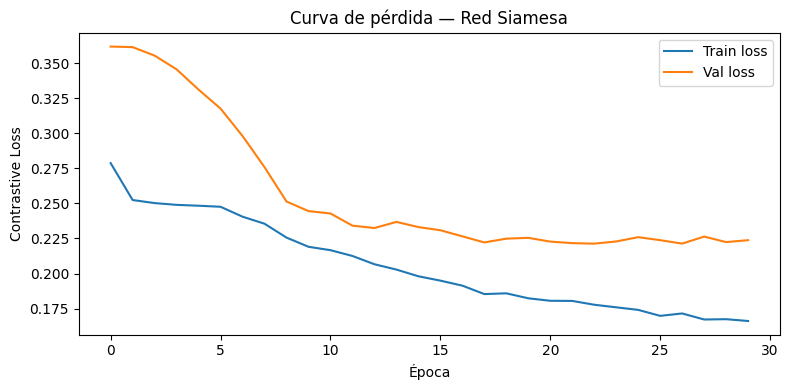

In [67]:
# perdida 

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"],   label="Val loss")
plt.xlabel("Época"); plt.ylabel("Contrastive Loss")
plt.title("Curva de pérdida — Red Siamesa")
plt.legend(); plt.tight_layout(); plt.show()


## Actividad 7 — Evaluación y visualización 

In [68]:
# distancias y etiquetas
from sklearn.metrics import roc_curve, auc, accuracy_score

siamese.eval()
all_distances, all_labels = [], []

with torch.no_grad():
    for img1, img2, labels in test_loader:
        img1, img2 = img1.to(device), img2.to(device)
        emb1, emb2 = siamese(img1, img2)
        d = torch.nn.functional.pairwise_distance(emb1, emb2, p=2)
        all_distances.extend(d.cpu().numpy())
        all_labels.extend(labels.numpy())

all_distances = np.array(all_distances)
all_labels    = np.array(all_labels)

print(f"Test pairs: {len(all_labels)}  |  positivos: {all_labels.sum()}  |  negativos: {(1-all_labels).sum()}")

Test pairs: 1000  |  positivos: 500  |  negativos: 500


In [69]:
# ROC + AUC + umbral 

scores = -all_distances

fpr, tpr, thresholds = roc_curve(all_labels, scores)
roc_auc = auc(fpr, tpr)

youden_idx = np.argmax(tpr - fpr)
umbral_dist = -thresholds[youden_idx]     
preds_opt   = (all_distances < umbral_dist).astype(int)
acc_opt     = accuracy_score(all_labels, preds_opt)

print(f"AUC:             {roc_auc:.4f}")
print(f"Umbral óptimo:   d < {umbral_dist:.4f}")
print(f"Accuracy óptimo: {acc_opt*100:.2f}%")


AUC:             0.6981
Umbral óptimo:   d < 0.4085
Accuracy óptimo: 65.40%


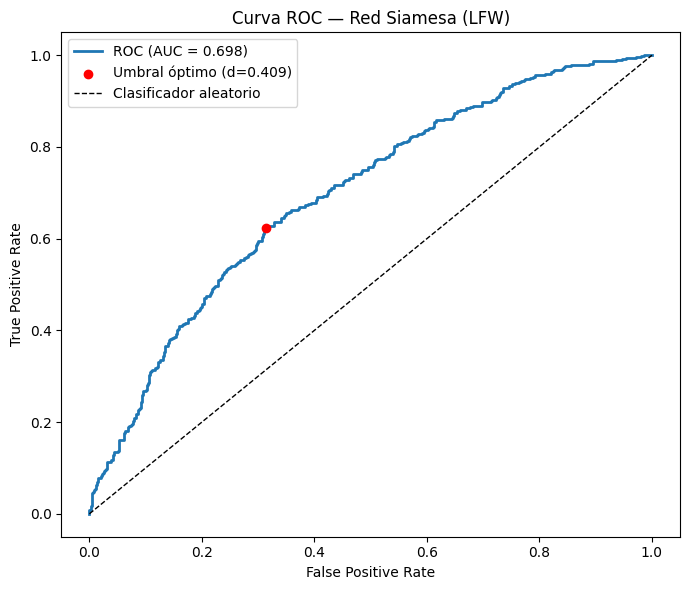

In [70]:
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
plt.scatter(fpr[youden_idx], tpr[youden_idx], color='red', zorder=5,
            label=f"Umbral óptimo (d={umbral_dist:.3f})")
plt.plot([0,1],[0,1],'k--', lw=1, label="Clasificador aleatorio")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Red Siamesa (LFW)")
plt.legend(); plt.tight_layout(); plt.show()


### Visualización con t-SNE: obtenga los embeddings de al menos 200 imágenes del conjunto de test, aplique t-SNE para reducir a 2 dimensiones y visualice el resultado coloreando cada punto por identidad. Interprete el gráfico: ¿qué tan separables son las identidades en el espacio aprendido?

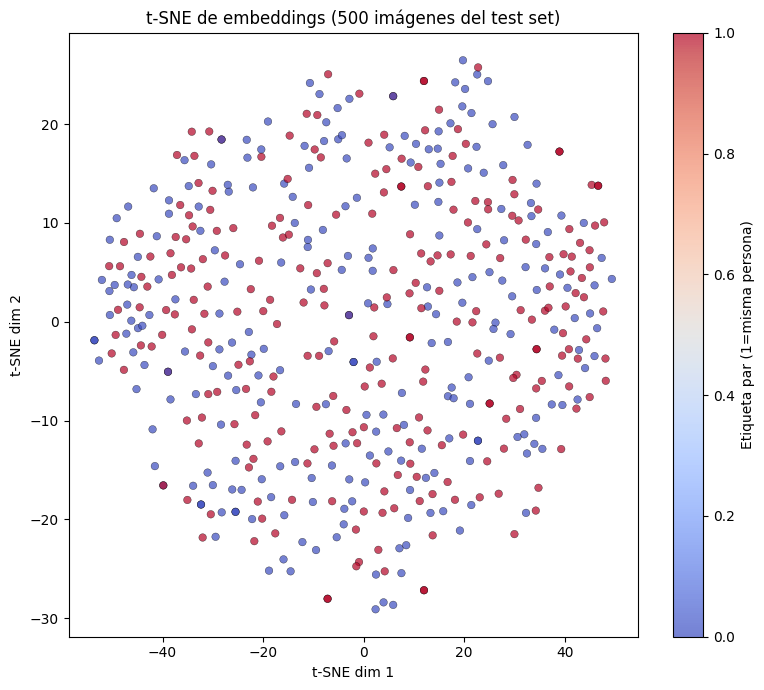

In [73]:
# t-SNE de embeddings 
from sklearn.manifold import TSNE

siamese.eval()
embs_list, id_labels = [], []
N_TSNE = 500

with torch.no_grad():
    for img1, img2, labels in test_loader:
        img1 = img1.to(device)
        emb1 = siamese.forward_one(img1)
        embs_list.append(emb1.cpu().numpy())
        id_labels.extend(labels.numpy())
        if sum(len(e) for e in embs_list) >= N_TSNE:
            break

embs_np   = np.concatenate(embs_list, axis=0)[:N_TSNE]
id_labels = np.array(id_labels)[:N_TSNE]

# t-SNE a 2D
tsne       = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
embs_2d    = tsne.fit_transform(embs_np)

# Visualizar (0 = distintas, 1 = misma persona — referido al par de origen)
plt.figure(figsize=(8, 7))
scatter = plt.scatter(embs_2d[:, 0], embs_2d[:, 1],
                      c=id_labels, cmap='coolwarm', alpha=0.7, s=30, edgecolors='k', lw=0.3)
plt.colorbar(scatter, label='Etiqueta par (1=misma persona)')
plt.title(f"t-SNE de embeddings ({N_TSNE} imágenes del test set)")
plt.xlabel("t-SNE dim 1"); plt.ylabel("t-SNE dim 2")
plt.tight_layout(); plt.show()


Lo primero que llama la atención es que no hay una separación clara entre los puntos rojos y azules. Ambos colores aparecen mezclados a lo largo de todo el espacio, sin formar clusters bien definidos por identidad. Esto es consistente con los errores que se ven en la parte (c).
Dicho esto, el gráfico tampoco es completamente aleatorio. Los resultados contrastantes entre el accuracy y esta visualización indican que el modelo aprendió algo pero no lo suficiente como para separar las identidades de forma robusta.

En resumen, el espacio de representación aprendido no es muy discriminativo. El modelo captura algunas características generales de los rostros, pero no logra organizar el espacio de manera que identidades distintas queden claramente separadas. Esto probablemente mejora con más épocas de entrenamiento, un backbone más potente, o una mejor estrategia de muestreo de tripletas durante el entrenamiento.

Total errores:      346
Falsos positivos:   157  (predijo MISMA, eran DISTINTAS)
Falsos negativos:   189  (predijo DISTINTA, eran MISMAS)


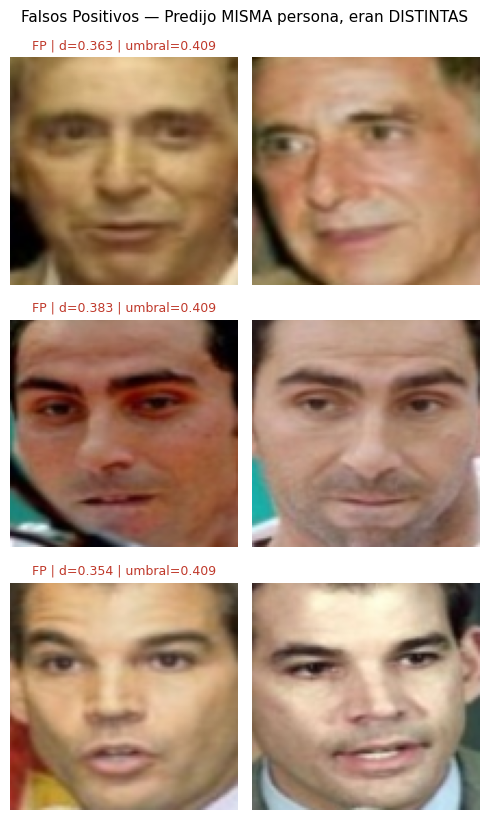

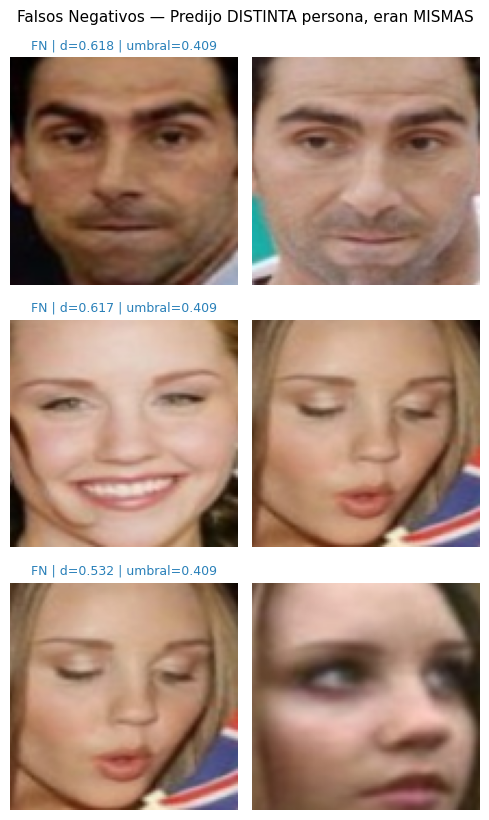

In [72]:
# errores

errores = np.where(preds_opt != all_labels)[0]
falsos_pos = [i for i in errores if preds_opt[i] == 1 and all_labels[i] == 0]  # predijo misma, eran distintas
falsos_neg = [i for i in errores if preds_opt[i] == 0 and all_labels[i] == 1]  # predijo distintas, eran mismas

print(f"Total errores:      {len(errores)}")
print(f"Falsos positivos:   {len(falsos_pos)}  (predijo MISMA, eran DISTINTAS)")
print(f"Falsos negativos:   {len(falsos_neg)}  (predijo DISTINTA, eran MISMAS)")

def mostrar_errores(indices, titulo, tipo, n=3):
    fig, axes = plt.subplots(n, 2, figsize=(5, n * 2.8))
    for row, idx in enumerate(indices[:n]):
        img1, img2, label = test_dataset[int(idx)]
        d = all_distances[idx]
        axes[row, 0].imshow(desnormalizar(img1)); axes[row, 0].axis('off')
        axes[row, 1].imshow(desnormalizar(img2)); axes[row, 1].axis('off')
        color = '#c0392b' if tipo == 'FP' else '#2980b9'
        axes[row, 0].set_title(f"{tipo} | d={d:.3f} | umbral={umbral_dist:.3f}",
                                fontsize=9, color=color)
    plt.suptitle(titulo, fontsize=11)
    plt.tight_layout(); plt.show()

mostrar_errores(falsos_pos, "Falsos Positivos — Predijo MISMA persona, eran DISTINTAS", "FP")
mostrar_errores(falsos_neg, "Falsos Negativos — Predijo DISTINTA persona, eran MISMAS", "FN")

### c) Análisis de errores: muestre al menos 3 pares donde el modelo comete errores (falsos positivos o falsos negativos) y discuta a qué podrían deberse.

El modelo cometió 346 errores en total: 157 falsos positivos y 189 falsos negativos.

Los tres pares de falsos positivos tienen distancias muy cercanas al umbral (0.354, 0.363, 0.383 vs umbral 0.409), lo que indica que el modelo estuvo "cerca" de acertar pero no lo suficiente. En los casos mostrados, los rostros comparten rasgos visuales similares: complexión parecida, misma franja etaria y tono de piel, y en algunos casos ángulos de fotografía similares. Esto sugiere que el modelo está priorizando características generales de apariencia en lugar de rasgos más discriminativos de identidad.

Para los falsos negativos los errores son más notorios. Las distancias son bastante más altas que el umbral (0.532 a 0.618), lo que indica que el modelo está bastante seguro de que son personas distintas cuando en realidad no lo son. Mirando los pares, la causa es bastante evidente: hay cambios importantes en iluminación, expresión facial y ángulo entre las dos fotos. En el caso de las dos mujeres jóvenes, una foto es frontal con buena luz y la otra está tomada desde otro ángulo con iluminación diferente, lo que altera significativamente el embedding generado.

Los errores siguen un patrón claro: los falsos positivos ocurren cuando dos personas distintas tienen una apariencia general similar, y los falsos negativos cuando la misma persona aparece en condiciones fotográficas muy distintas. Ambos tipos de error apuntan a la misma limitación: el modelo es sensible a variaciones en iluminación y pose, y no siempre logra capturar rasgos de identidad suficientemente robustos. Con más datos de entrenamiento por identidad y mayor variedad de condiciones fotográficas, se esperaría reducir especialmente los falsos negativos.

